In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from pathlib import Path
import re

In [40]:
data_folder = Path('/astrum/home/hpchzy/code/data/20260603/camd9554n2/output_filt/20260603-232330')

# data_folder = Path("/astrum/home/hpchzy/code/data/20260601/cgnr6760pn2/output_tvkern_filt/20260601-215336/") #tvkern

# data_folder = Path("/astrum/home/hpchzy/code/data/20260601/cgnr6760pn2/output_filt/20260601-194220/") #fix likwid
# data_folder = Path("/astrum/home/hpchzy/code/data/20260601/cgnr6760pn2/output_filt/20260601-192830/") #fix tsc_ns,512,double sub
# data_folder = Path("/astrum/home/hpchzy/code/data/20260601/cgnr6760pn2/output_filt/20260601-191813/")
# data_folder = Path("/astrum/home/hpchzy/code/data/20260601/cgnr6760pn2/output_filt/20260601-191251/")

# data_folder = Path("/astrum/home/hpchzy/code/data/20260529/camd9554n2/output_filt/20260529-202148/")

/astrum/home/hpchzy/code/data/20260603/camd9554n2/output_filt/20260603-232330/jacobi2d5p_cgt_np64_size2048_filt/tr_hist.csv
/astrum/home/hpchzy/code/data/20260603/camd9554n2/output_filt/20260603-232330/jacobi2d5p_wtime_np64_size2048_filt/tr_hist.csv
/astrum/home/hpchzy/code/data/20260603/camd9554n2/output_filt/20260603-232330/jacobi2d5p_tsc_np64_size2048_filt/tr_hist.csv
/astrum/home/hpchzy/code/data/20260603/camd9554n2/output_filt/20260603-232330/jacobi2d5p_likwid_np64_size2048_filt/tr_hist.csv
/astrum/home/hpchzy/code/data/20260603/camd9554n2/output_filt/20260603-232330/jacobi2d5p_tsc_native_np64_size2048_filt/tr_hist.csv
/astrum/home/hpchzy/code/data/20260603/camd9554n2/output_filt/20260603-232330/jacobi2d5p_papi_np64_size2048_filt/tr_hist.csv
/astrum/home/hpchzy/code/data/20260603/camd9554n2/output_filt/20260603-232330/jacobi2d5p_papix6_np64_size2048_filt/tr_hist.csv


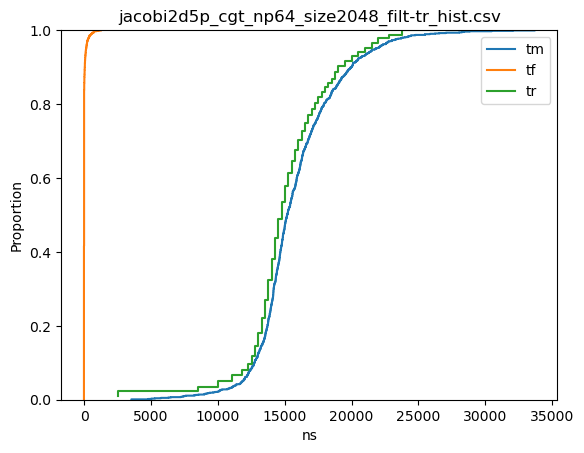

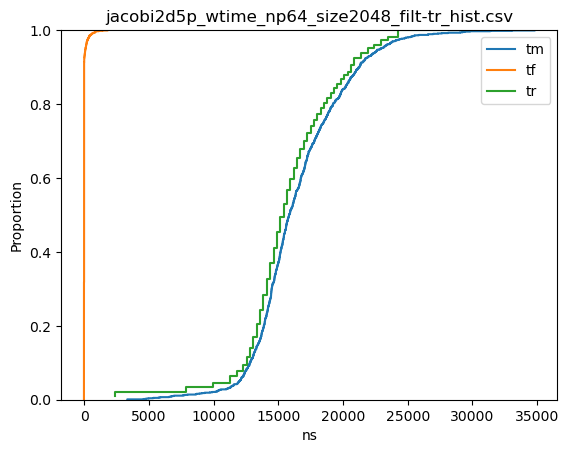

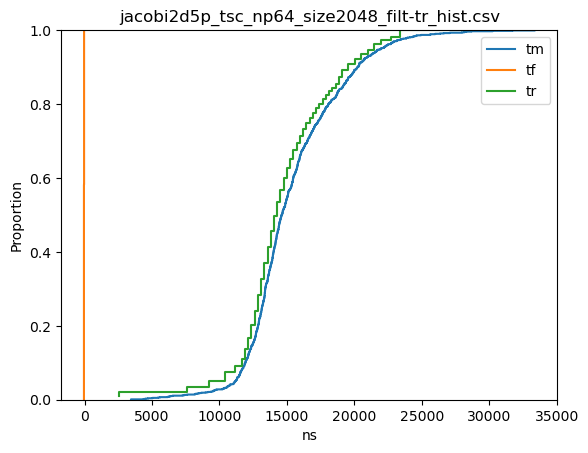

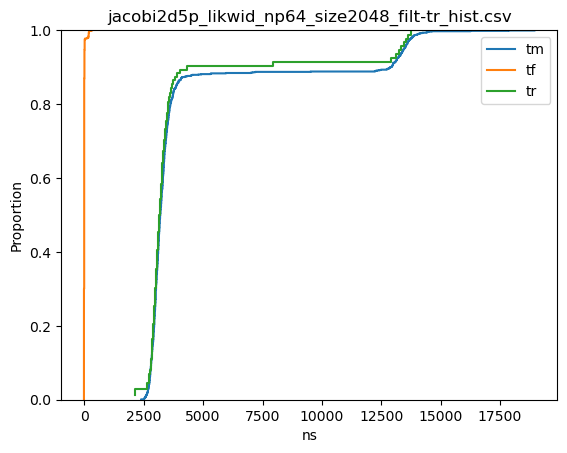

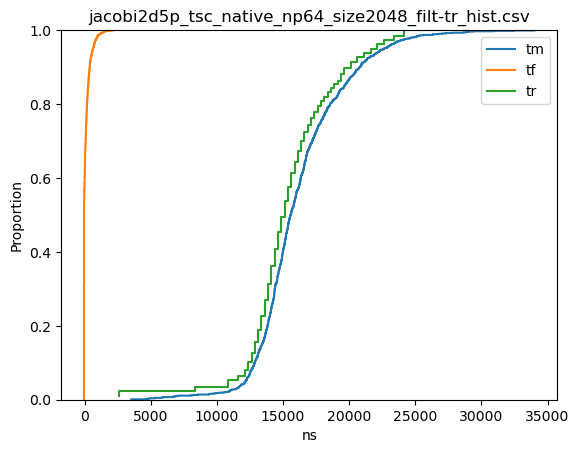

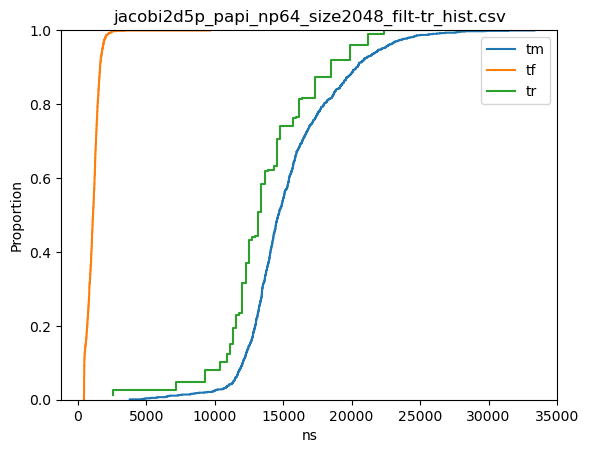

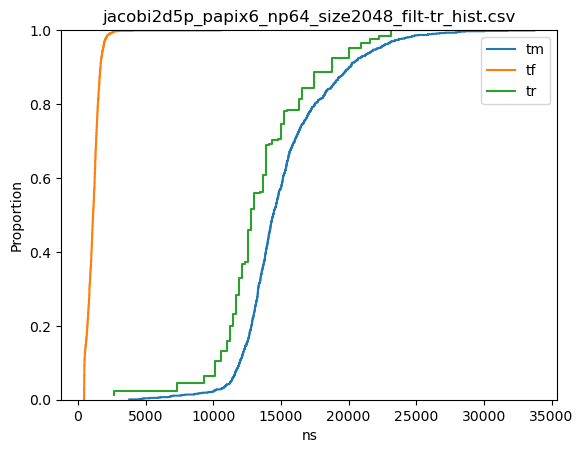

In [41]:
for tr_hist_file in data_folder.glob("*/tr_hist.csv"):
    print(tr_hist_file)
    tm_file = tr_hist_file.parent / "met.csv"
    tf_file = tr_hist_file.parent / "tf.csv"
    tm_hist_file = tr_hist_file.parent / "tm_hist.csv"
    sim_cdf_file = tr_hist_file.parent / "sim_cdf.csv"

    m = re.search(r"(?P<kernel>.*)_(?P<timer>.*)_np(?P<np>\d+)_size(?P<size>\d+)_filt", tr_hist_file.parent.name)
    # print(m.groupdict())


    tm_df = pd.read_csv(tm_file, header=None, names=["ns"])
    tm_sorted = tm_df.sort_values(by="ns")
    tm_sampled = tm_sorted.sample(n=1000, random_state=42)

    tf_df = pd.read_csv(tf_file, header=None, names=["ns"])
    tf_sorted = tf_df.sort_values(by="ns")
    tf_sampled = tf_sorted.sample(n=1000, random_state=42)

    tr_hist_df = pd.read_csv(tr_hist_file, header=None, names=["ns", "prob"])
    tr_hist_df.sort_values(by="ns", inplace=True)
    tr_hist_df["cdf"] = tr_hist_df["prob"].cumsum()

    fig, ax = plt.subplots()
    # sns.histplot(tm_sampled["tm"], bins=20, kde=True)
    sns.ecdfplot(tm_sampled["ns"], ax=ax, label="tm")
    sns.ecdfplot(tf_sampled["ns"], ax=ax, label="tf")

    ax.step(tr_hist_df["ns"], tr_hist_df["cdf"], label="tr")

    # tr_ns = tr_hist_df["ns"].to_numpy()
    # tr_cdf = tr_hist_df["cdf"].to_numpy()
    # tr_ns_smooth = np.linspace(tr_ns.min(), tr_ns.max(), 1000)
    # tr_cdf_smooth = np.interp(tr_ns_smooth, tr_ns, tr_cdf)
    # ax.plot(tr_ns_smooth, tr_cdf_smooth, label="tr")

    ax.set_title(f"{tr_hist_file.parent.name}-{tr_hist_file.name}")

    ax.legend()
    # sns.histplot(tm_sampled["tm"], stat="density", bins=20, kde=True)
    
